# RL CAPTCHA — Three Algorithms in One Notebook

This notebook walks through the full reinforcement-learning pipeline used by the `rl_captcha` package for bot detection. It covers **three policy-gradient algorithms**, all built on the same LSTM actor-critic backbone:

1. **PPO** — Proximal Policy Optimization with a clipped surrogate objective.
2. **DG** — Delightful Policy Gradients (arXiv:2603.14608), which gates each gradient term by a sigmoid of the "delight" signal.
3. **Soft PPO** — PPO with an automatically tuned entropy temperature α (SAC-style dual gradient descent).

Every algorithm observes the same windowed telemetry features (mouse / click / keystroke / scroll statistics) and chooses an action from `{continue, deploy_honeypot, easy_puzzle, medium_puzzle, hard_puzzle, allow, block}`.

### What this notebook does
- Loads session data **directly from `src/data/`** (human, bot, augmented-bot).
- Explores the dataset and saves summary figures to `src/notebook_figures/`.
- Explains the LSTM-on-windows environment and visualizes window features.
- Trains all three algorithms on a short budget (runs in minutes, not hours).
- Plots autogenerated learning curves and a side-by-side comparison.
- Evaluates each trained agent on the held-out validation set.

### How to use this notebook
Run cells from top to bottom. The demo timestep budget (`DEMO_TIMESTEPS`) is intentionally small so you can run the whole notebook end-to-end. To reproduce the full 500k-step results described in `rl_captcha/README.md`, use the `train_ppo.py` CLI script instead of this notebook.

---
## 1. Setup

Set up imports, resolve paths, and create the figures output directory.

In [1]:
# Standard library for filesystem paths
from pathlib import Path
# NumPy powers every metric / array computation in the notebook
import numpy as np
# Matplotlib renders every figure
import matplotlib.pyplot as plt
# Seaborn gives matplotlib a cleaner default look
import seaborn as sns
# PyTorch backs the LSTM actor-critic network inside each agent
import torch
# `replace` lets us tweak a frozen dataclass (EventEnvConfig) without mutation side-effects
from dataclasses import replace
# `defaultdict` is handy for accumulating per-rollout training metrics
from collections import defaultdict
# Render plots inline inside the notebook
%matplotlib inline
# Apply a consistent visual style everywhere
sns.set_style("whitegrid")
# Crisper default figure resolution
plt.rcParams["figure.dpi"] = 110

In [2]:
# This notebook lives at src/rl_algorithms.ipynb so imports of the form `rl_captcha.X` resolve naturally
NOTEBOOK_DIR = Path.cwd()
# Root of all telemetry data — subfolders: human/, bot/, bot_augmented/
DATA_DIR = NOTEBOOK_DIR / "data"
# Output directory where every autogenerated figure from this notebook is saved
FIGURES_DIR = NOTEBOOK_DIR / "notebook_figures"
# Create the figures directory if it is not already present
FIGURES_DIR.mkdir(exist_ok=True)
# Fail fast if the data folder is missing so the reader knows what went wrong
assert DATA_DIR.is_dir(), f"Data directory not found: {DATA_DIR}"
# Echo the resolved paths so the reader can sanity-check their working directory
print(f"Notebook dir : {NOTEBOOK_DIR}")
print(f"Data dir     : {DATA_DIR}")
print(f"Figures dir  : {FIGURES_DIR}")

Notebook dir : C:\Users\megha\OneDrive\Desktop\group-project-team-25\src
Data dir     : C:\Users\megha\OneDrive\Desktop\group-project-team-25\src\data
Figures dir  : C:\Users\megha\OneDrive\Desktop\group-project-team-25\src\notebook_figures


---
## 2. Load the Data

The `load_from_directory` helper reads every JSON file under `data/human/`, `data/bot/`, and optionally `data/bot_augmented/`. Each file is normalized into a `Session` dataclass containing mouse, click, keystroke, and scroll event lists, plus metadata (bot_type, tier, source_file, etc.).

In [3]:
# Import the unified directory loader and supporting helpers
from rl_captcha.data.loader import load_from_directory, split_sessions, bot_type_to_tier, TIER_NAMES
# Load every session. include_augmented=True pulls in data/bot_augmented/ too
sessions = load_from_directory(DATA_DIR, include_augmented=True)
# Print the total so we know loading succeeded
print(f"Loaded {len(sessions)} sessions total")

  Loaded 2610 augmented bot files from C:\Users\megha\OneDrive\Desktop\group-project-team-25\src\data\bot_augmented/
Loaded 3249 sessions total


In [4]:
# Split sessions by label to inspect the class balance
human_sessions = [s for s in sessions if s.label == 1]
# Bot sessions include originals plus any adversarially augmented copies
bot_sessions = [s for s in sessions if s.label == 0]
# Augmented copies are tagged either by `_aug_` in the id or by metadata["augmented"]
aug_sessions = [s for s in bot_sessions if s.metadata.get("augmented") or "_aug_" in s.session_id]
# Original bot traces are the ones that are not augmented copies
orig_bot_sessions = [s for s in bot_sessions if s not in aug_sessions]
# Show the breakdown so the reader can confirm the distribution
print(f"Human sessions      : {len(human_sessions)}")
print(f"Bot sessions (orig) : {len(orig_bot_sessions)}")
print(f"Bot sessions (aug)  : {len(aug_sessions)}")

Human sessions      : 203
Bot sessions (orig) : 436
Bot sessions (aug)  : 2610


### 2.1 Dataset composition
A quick bar chart of the three categories. Saved to `notebook_figures/01_dataset_composition.png`.

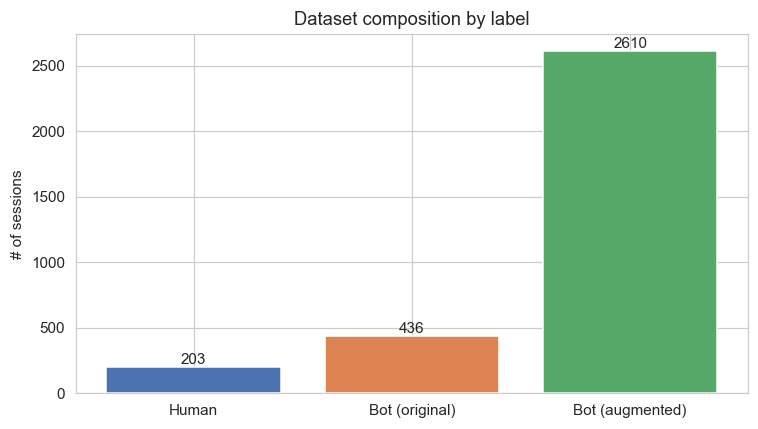

In [5]:
# Create a small figure summarizing the three session categories
fig, ax = plt.subplots(figsize=(7, 4))
# Labels for each bar
categories = ["Human", "Bot (original)", "Bot (augmented)"]
# Matching counts pulled from the previous cell
counts = [len(human_sessions), len(orig_bot_sessions), len(aug_sessions)]
# Distinct colors for visual clarity
colors = ["#4C72B0", "#DD8452", "#55A868"]
# Draw the bar chart
bars = ax.bar(categories, counts, color=colors)
# Annotate each bar with its count on top
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), str(c), ha="center", va="bottom", fontsize=10)
# Axis labels and title so the figure stands alone in reports
ax.set_ylabel("# of sessions")
ax.set_title("Dataset composition by label")
# Tidy the layout to avoid clipped labels
fig.tight_layout()
# Persist the figure to disk and render inline
fig.savefig(FIGURES_DIR / "01_dataset_composition.png")
plt.show()

### 2.2 Bot distribution by adversarial tier
Bots are partitioned into five tiers of increasing sophistication (T1 commodity → T5 LLM-powered). This figure shows how many bot sessions fall in each tier.

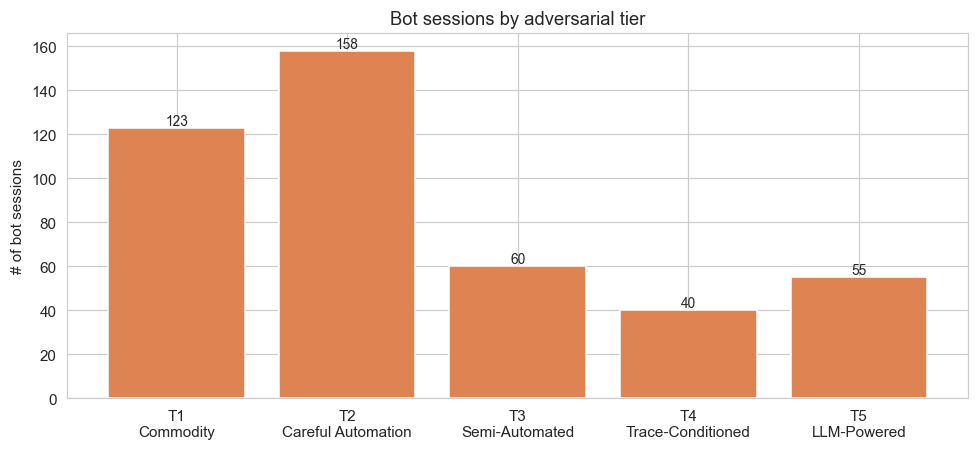

In [6]:
# Count bot sessions by adversarial tier 1-5
tier_counts = defaultdict(int)
# Count originals only; augmented copies inherit the source tier so including them would double-count
for s in orig_bot_sessions:
    # Prefer explicit `tier` field in metadata; fall back to mapping bot_type -> tier
    tier = s.metadata.get("tier") or bot_type_to_tier(s.metadata.get("bot_type"))
    tier_counts[int(tier)] += 1
# Sort tiers in ascending order for a left-to-right visual
tiers_sorted = sorted(tier_counts.keys())
# Build nice labels like "T1\nCommodity" using the TIER_NAMES mapping
tier_labels = [f"T{t}\n{TIER_NAMES.get(t, 'unknown')}" for t in tiers_sorted]
# Matching count for each tier, in the same order
tier_values = [tier_counts[t] for t in tiers_sorted]
# Build the figure
fig, ax = plt.subplots(figsize=(9, 4.2))
# Plot the bars with the shared bot color
ax.bar(tier_labels, tier_values, color="#DD8452")
# Axis labels
ax.set_ylabel("# of bot sessions")
ax.set_title("Bot sessions by adversarial tier")
# Annotate counts on top of each bar
for i, v in enumerate(tier_values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
# Layout + save
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_bot_tiers.png")
plt.show()

### 2.3 Raw event-count distribution
How much telemetry does each session contain? This histogram shows the total event count (mouse + click + key + scroll) per session, split by label.

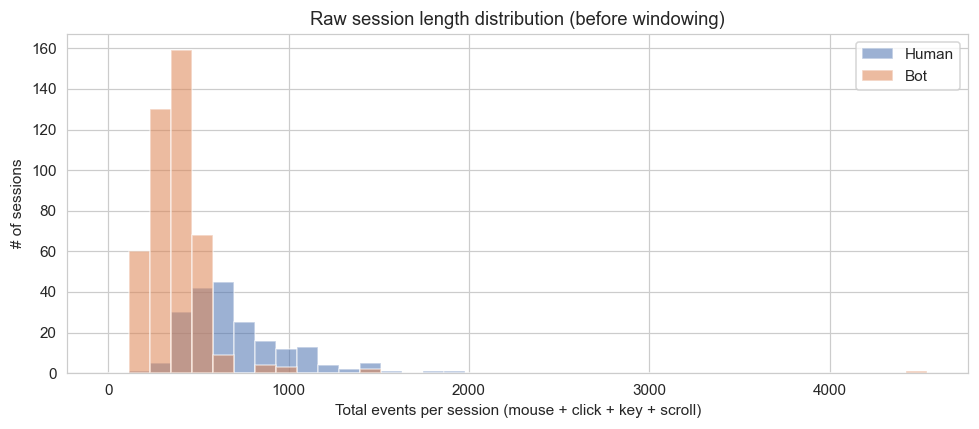

In [7]:
# Helper: total event count for a single session across all four streams
def _total_events(s):
    # Sum the four event lists — this is the raw telemetry length before windowing
    return len(s.mouse) + len(s.clicks) + len(s.keystrokes) + len(s.scroll)

# Compute event counts for humans and original bots separately
human_lens = np.array([_total_events(s) for s in human_sessions])
bot_lens = np.array([_total_events(s) for s in orig_bot_sessions])
# Build a shared-axes histogram
fig, ax = plt.subplots(figsize=(9, 4))
# Shared bins so the two distributions are comparable
max_len = max(human_lens.max() if len(human_lens) else 0, bot_lens.max() if len(bot_lens) else 0)
bins = np.linspace(0, max_len + 1, 40)
# Draw overlapping translucent histograms
ax.hist(human_lens, bins=bins, alpha=0.55, label="Human", color="#4C72B0")
ax.hist(bot_lens, bins=bins, alpha=0.55, label="Bot", color="#DD8452")
# Axes and title
ax.set_xlabel("Total events per session (mouse + click + key + scroll)")
ax.set_ylabel("# of sessions")
ax.set_title("Raw session length distribution (before windowing)")
ax.legend()
# Layout + save
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_event_counts.png")
plt.show()

---
## 3. Environment & Train/Val/Test Split

`EventEnv` is a Gymnasium environment where **one timestep = one window of 30 events**. An episode = all windows of a single session, presented sequentially to the LSTM.

**Action masking:** non-final windows only allow `continue` or `deploy_honeypot`. The final window only allows terminal actions (`easy/medium/hard_puzzle`, `allow`, `block`). This is enforced by masking invalid logits to `-inf` before softmax.

We use a stratified 70/15/15 split where augmented copies follow their source session into the same split (no leakage).

In [8]:
# Import the windowed environment and the action-name table
from rl_captcha.environment.event_env import EventEnv, ACTION_NAMES
# Top-level Config bundles EventEnvConfig, PPOConfig, and DB paths in one object
from rl_captcha.config import Config
# Instantiate defaults
cfg = Config()
# Stratified 70/15/15 split keyed by label; seed=42 matches train_ppo.py
train_sessions, val_sessions, test_sessions = split_sessions(
    sessions, train=0.70, val=0.15, test=0.15, seed=42,
)
# Training env: augmentation ON so the agent sees noisy timelines
train_env = EventEnv(train_sessions, config=cfg.event_env)
# Validation env: augmentation OFF for stable, comparable metrics
val_cfg = replace(cfg.event_env, augment=False)
val_env = EventEnv(val_sessions, config=val_cfg)
# Test env also runs on raw (un-augmented) data
test_env = EventEnv(test_sessions, config=val_cfg)
# Report split sizes
print(f"Train : {len(train_sessions)} sessions")
print(f"Val   : {len(val_sessions)} sessions")
print(f"Test  : {len(test_sessions)} sessions")
# Show the action set the agent chooses between
print(f"Action set ({len(ACTION_NAMES)}): {ACTION_NAMES}")

Train : 2271 sessions
Val   : 485 sessions
Test  : 493 sessions
Action set (7): ['continue', 'deploy_honeypot', 'easy_puzzle', 'medium_puzzle', 'hard_puzzle', 'allow', 'block']


In [9]:
# Reset the training env once to see an example first-window observation
obs, info = train_env.reset()
# Report which session we landed on and its ground-truth label
print(f"Session: {info['session_id']}")
print(f"  label={info['true_label']} (1=human, 0=bot), total_windows={info['total_windows']}")
# Print the 26-dim feature vector (rounded for readability)
print("\nFirst window feature vector (26 dims):")
print(np.round(obs, 3))
# Show which actions are valid on this first window (should be continue + honeypot only)
print(f"\nValid action mask: {info['action_mask']}")

Session: 8a9e366f-fb12-40ec-bfb0-b066d1b20752
  label=1 (1=human, 0=bot), total_windows=57

First window feature vector (26 dims):
[0.233 0.033 0.    0.733 0.583 0.558 1.    0.439 0.431 0.    0.054 0.
 0.    0.    0.    0.    0.    0.292 0.    0.08  0.06  0.213 0.129 1.
 0.638 1.   ]

Valid action mask: [1. 1. 0. 0. 0. 0. 0.]


### 3.1 Feature distributions: Human vs Bot
The 26-dim feature vector captures behavioral patterns. Bots typically have **low speed variance, low timing variance, and straighter paths** than humans. We collect the first-window feature vector for a sample of each class and plot the distributions.

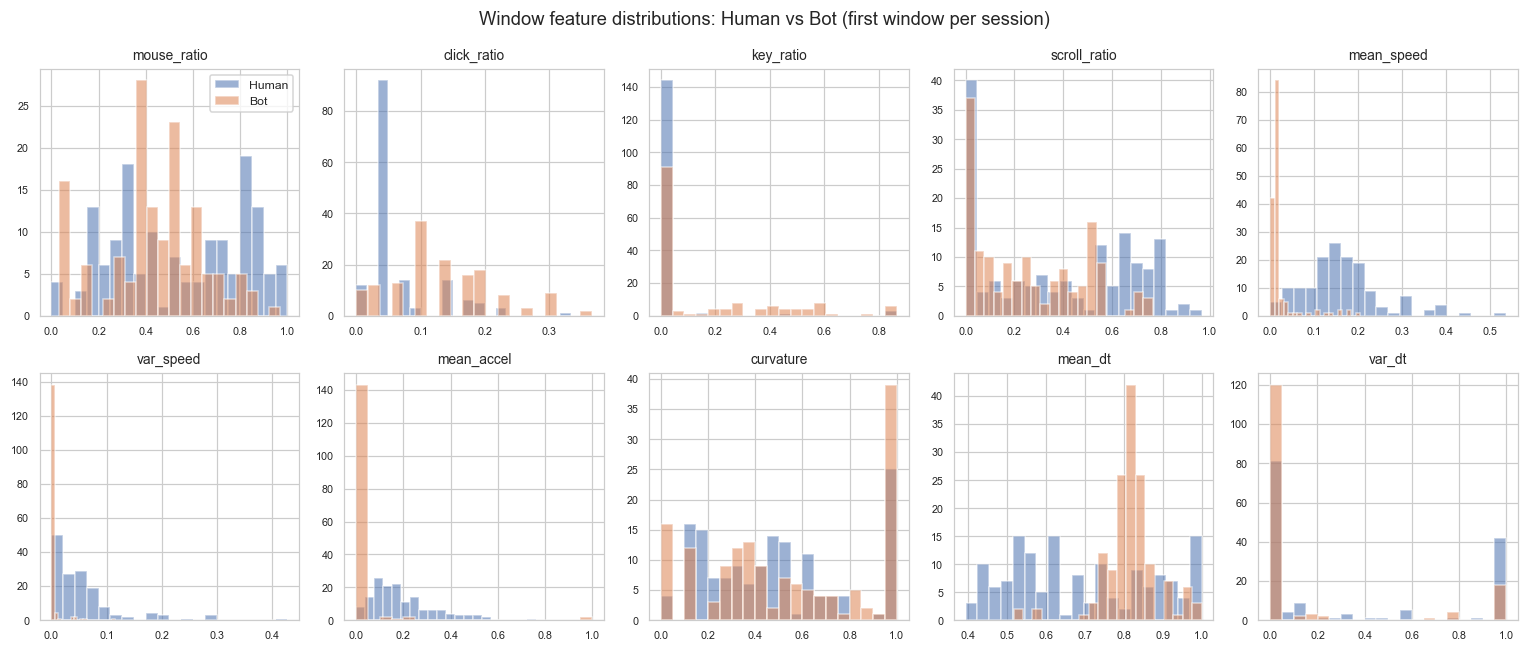

In [10]:
# Build two small single-class envs so we can sample human vs bot features in isolation
sample_cfg = replace(cfg.event_env, augment=False)
# Cap sample sizes to keep the sampling loop fast
N_SAMPLE = 150
human_env = EventEnv(human_sessions[:N_SAMPLE] or human_sessions, config=sample_cfg)
bot_env = EventEnv(orig_bot_sessions[:N_SAMPLE] or orig_bot_sessions, config=sample_cfg)

# Helper: collect the first-window feature vector from `n` reset() calls
def _collect_first_windows(env, n):
    feats = []
    for _ in range(n):
        # Reset returns a fresh session's first-window observation
        o, inf = env.reset()
        # Skip sessions below the min-events threshold (they return zero vectors)
        if inf.get("too_short"):
            continue
        feats.append(o)
    # Stack into an (n, 26) matrix, or return an empty matrix if no valid samples
    return np.stack(feats) if feats else np.zeros((0, 26))

# Gather first-window features for both populations
human_feats = _collect_first_windows(human_env, 150)
bot_feats = _collect_first_windows(bot_env, 150)
# Feature names for the first 10 dims — matches the encoder docstring in event_env.py
feat_names = [
    "mouse_ratio", "click_ratio", "key_ratio", "scroll_ratio",
    "mean_speed", "var_speed", "mean_accel", "curvature",
    "mean_dt", "var_dt",
]
# 2x5 grid of histograms — one per feature
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, (ax, name) in enumerate(zip(axes.ravel(), feat_names)):
    # Draw translucent histograms so overlaps are visible
    ax.hist(human_feats[:, i], bins=20, alpha=0.55, color="#4C72B0", label="Human")
    ax.hist(bot_feats[:, i], bins=20, alpha=0.55, color="#DD8452", label="Bot")
    # Small title per subplot so each feature is labeled
    ax.set_title(name, fontsize=9)
    ax.tick_params(labelsize=7)
# Legend on the first subplot is enough for the whole grid
axes[0, 0].legend(fontsize=8)
# Overall figure title
fig.suptitle("Window feature distributions: Human vs Bot (first window per session)")
fig.tight_layout()
# Save and show
fig.savefig(FIGURES_DIR / "04_feature_distributions.png")
plt.show()

---
## 4. Shared Training & Plotting Helpers

All three algorithms use the **same rollout collection loop** and the **same LSTM actor-critic network**. They differ only in their `update()` methods. We define helpers once and reuse them for every algorithm below.

In [11]:
# Import all three agent classes and their config extensions
from rl_captcha.agent.ppo_lstm import PPOLSTM
from rl_captcha.agent.dg_lstm import DGLSTM, DGConfig
from rl_captcha.agent.soft_ppo_lstm import SoftPPOLSTM, SoftPPOConfig


# Generic rollout collection: step the env, push transitions into the agent's buffer
def _collect_rollout(env, agent, num_steps):
    # Episode rewards collected for logging / learning-curve plotting
    episode_rewards = []
    # Reset the env and seed the agent's LSTM hidden state
    obs, info = env.reset()
    agent.reset_hidden()
    # Skip sessions below the min_events threshold (they have no valid windows)
    while info.get("too_short"):
        obs, info = env.reset()
        agent.reset_hidden()
    # Track cumulative reward for the in-flight episode
    ep_reward = 0.0
    # The action mask controls which actions the policy is allowed to sample
    action_mask = info.get("action_mask")
    done = False
    # Collect exactly `num_steps` transitions
    for _ in range(num_steps):
        # Sample an action from the current stochastic policy (masked)
        action, log_prob, value = agent.select_action(obs, action_mask=action_mask)
        # Advance one step in the environment
        next_obs, reward, terminated, truncated, step_info = env.step(action)
        # Episode ends on terminal action (puzzle/allow/block) or truncation
        done = terminated or truncated
        # Push the (obs, action, reward, done, logp, value, mask) tuple into the rollout buffer
        agent.buffer.push(obs, action, reward, done, log_prob, value, action_mask=action_mask)
        ep_reward += reward
        if done:
            # Episode just ended — record its total reward and start a new one
            episode_rewards.append(ep_reward)
            ep_reward = 0.0
            obs, info = env.reset()
            agent.reset_hidden()
            while info.get("too_short"):
                obs, info = env.reset()
                agent.reset_hidden()
            action_mask = info.get("action_mask")
        else:
            # Continue the same episode with the next observation + updated mask
            obs = next_obs
            action_mask = step_info.get("action_mask")
    # Bootstrap value for GAE: 0 if we just ended an episode, else V(last obs)
    last_value = agent.get_value(obs) if not done else 0.0
    return {"last_value": last_value, "episode_rewards": episode_rewards}


# Generic training loop — works for any PPO/DG/Soft-PPO agent
def train_agent(agent, env, total_timesteps, rollout_steps, label):
    # Collect per-rollout metrics here; default to empty lists
    history = defaultdict(list)
    # Track cumulative env transitions consumed
    steps = 0
    # Rollout counter for printing progress lines
    rollout_num = 0
    # Keep training until we've consumed the requested step budget
    while steps < total_timesteps:
        rollout_num += 1
        # Clear the buffer before each rollout
        agent.buffer.reset()
        # Collect fresh on-policy experience
        stats = _collect_rollout(env, agent, rollout_steps)
        # Bootstrap + GAE produce per-step advantages and returns
        agent.buffer.compute_gae(
            last_value=stats["last_value"],
            gamma=agent.config.gamma,
            gae_lambda=agent.config.gae_lambda,
        )
        # Each agent's own update() defines its algorithm: PPO clip, DG gate, or Soft PPO α
        update_metrics = agent.update()
        # Count the transitions we just consumed (may be less than rollout_steps on buffer edges)
        steps += agent.buffer.ptr
        # Mean episode reward for the learning curve
        rew = stats["episode_rewards"]
        history["reward"].append(float(np.mean(rew)) if rew else 0.0)
        # Track cumulative env steps for x-axes
        history["steps"].append(steps)
        # Persist every update metric the agent returned (policy_loss, entropy, delight, alpha, ...)
        for k, v in update_metrics.items():
            history[k].append(v)
        # Print progress every 2 rollouts so the notebook doesn't look stuck
        if rollout_num % 2 == 0 or steps >= total_timesteps:
            mean_r = history["reward"][-1]
            ent = update_metrics.get("entropy", 0.0)
            print(f"[{label}] rollout {rollout_num} | steps {steps}/{total_timesteps} | mean reward {mean_r:+.3f} | entropy {ent:.3f}")
    return history

In [12]:
# Helper: standard 2x2 learning-curves figure (reward / policy loss / value loss / entropy)
def plot_training_curves(history, label, out_path, color="#4C72B0"):
    # X-axis is cumulative env steps; metrics are logged once per rollout
    x = np.array(history["steps"])
    # Pull each metric, defaulting to an empty array if the agent didn't return it
    reward = np.array(history.get("reward", []))
    policy_loss = np.array(history.get("policy_loss", []))
    value_loss = np.array(history.get("value_loss", []))
    entropy = np.array(history.get("entropy", []))
    # 2x2 grid — one subplot per metric
    fig, axes = plt.subplots(2, 2, figsize=(11, 7))
    # Top-left: mean episode reward over training
    axes[0, 0].plot(x, reward, marker="o", color=color)
    axes[0, 0].set_title("Mean episode reward")
    axes[0, 0].set_xlabel("Env steps")
    # Top-right: policy loss
    if len(policy_loss) == len(x):
        axes[0, 1].plot(x, policy_loss, marker="o", color=color)
    axes[0, 1].set_title("Policy loss")
    axes[0, 1].set_xlabel("Env steps")
    # Bottom-left: value loss
    if len(value_loss) == len(x):
        axes[1, 0].plot(x, value_loss, marker="o", color=color)
    axes[1, 0].set_title("Value loss")
    axes[1, 0].set_xlabel("Env steps")
    # Bottom-right: policy entropy (exploration signal)
    if len(entropy) == len(x):
        axes[1, 1].plot(x, entropy, marker="o", color=color)
    axes[1, 1].set_title("Policy entropy")
    axes[1, 1].set_xlabel("Env steps")
    # Supertitle + layout + save
    fig.suptitle(f"{label} training curves")
    fig.tight_layout()
    fig.savefig(out_path)
    plt.show()

In [13]:
# Demo budget — small so the whole notebook runs end-to-end in minutes.
# For full-scale runs (500k timesteps) use the train_ppo.py CLI script instead.
DEMO_TIMESTEPS = 10_000
# Rollout size balances update frequency vs. gradient-estimate variance
DEMO_ROLLOUT = 1024
# Apply the smaller rollout size to the shared config so every agent uses it
cfg.ppo.rollout_steps = DEMO_ROLLOUT
# Dimension of the observation vector comes from the encoder
OBS_DIM = cfg.event_env.event_dim
# The action space has 7 discrete actions (see ACTION_NAMES above)
ACTION_DIM = 7

---
## 5. Algorithm 1 — PPO (Proximal Policy Optimization)

PPO is the baseline. For each rollout it performs multiple epochs of a **clipped surrogate update**:

$$L^{CLIP}(\theta) = \mathbb{E}_t\left[\min\big(r_t(\theta) A_t,\ \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon) A_t\big)\right]$$

where $r_t(\theta) = \pi_\theta(a_t|s_t) / \pi_{\theta_{old}}(a_t|s_t)$ is the importance ratio.

**Why the clip?** It prevents huge policy updates when an action's probability has drifted far from the behavior policy — keeping training on-policy *enough* to converge.

**Full loss:** `L_clip + c_v · L_value − c_h · H(π)` where `L_value` is a clipped squared-error value loss and `H(π)` is an entropy bonus that keeps the policy exploring.

In [14]:
# Instantiate a fresh PPO agent — LSTM actor-critic + clipped surrogate update
ppo_agent = PPOLSTM(
    # Observation dim matches the 26-dim windowed feature vector
    obs_dim=OBS_DIM,
    # 7 discrete actions (continue / honeypot / 3 puzzles / allow / block)
    action_dim=ACTION_DIM,
    # Share the PPO hyperparameters (lr, gamma, clip_eps, etc.) from the main config
    config=cfg.ppo,
    # Use CPU for the demo; switch to "cuda" for full-scale runs if a GPU is available
    device="cpu",
)
# Train PPO and collect per-rollout metrics for plotting
ppo_history = train_agent(ppo_agent, train_env, DEMO_TIMESTEPS, DEMO_ROLLOUT, "PPO")

[PPO] rollout 2 | steps 2048/10000 | mean reward +0.291 | entropy 0.725


[PPO] rollout 4 | steps 4096/10000 | mean reward +0.448 | entropy 0.674


[PPO] rollout 6 | steps 6144/10000 | mean reward +0.774 | entropy 0.661


[PPO] rollout 8 | steps 8192/10000 | mean reward +0.937 | entropy 0.655


[PPO] rollout 10 | steps 10240/10000 | mean reward +0.995 | entropy 0.603


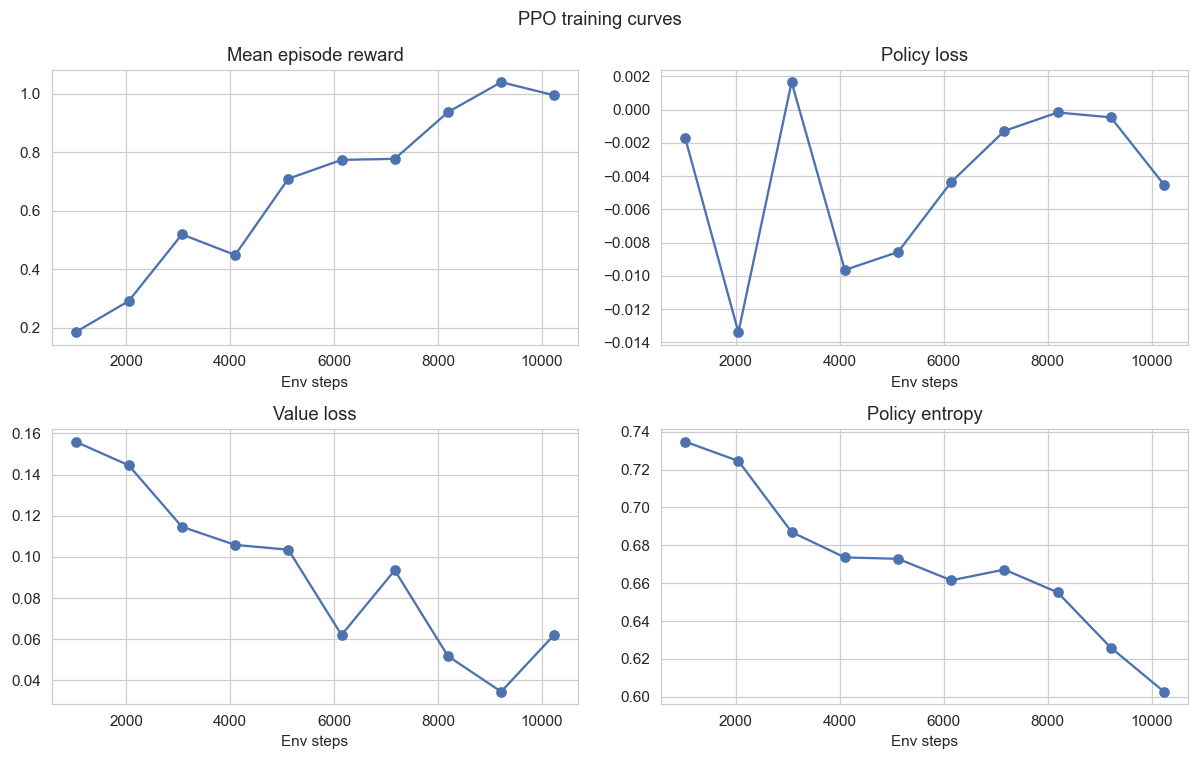

In [15]:
# Render the 2x2 learning-curves figure and save it
plot_training_curves(
    ppo_history,
    "PPO",
    FIGURES_DIR / "05_ppo_training.png",
    color="#4C72B0",
)

---
## 6. Algorithm 2 — DG (Delightful Policy Gradients)

DG (arXiv:2603.14608) is a drop-in replacement for the vanilla policy gradient that **gates each gradient term by a sigmoid of the "delight" signal**. For each transition:

- **Surprisal:** $\ell_t = -\log \pi_\theta(a_t | h_t)$ — how surprising the action was under the current policy.
- **Delight:** $\chi_t = U_t \cdot \ell_t$ — advantage × surprisal. Large and positive when a rare action pays off; large and negative when a rare action flops.
- **Gate:** $w_t = \sigma(\chi_t / \eta) \in (0, 1)$.
- **Update:** $\Delta\theta \mathrel{{+}{=}} w_t \cdot U_t \cdot \nabla_\theta \log \pi_\theta(a_t | h_t)$.

**Why?** Standard policy gradients have two pathologies: (1) very noisy gradients from rare bad actions (within-context variance), and (2) gradient budget wasted on already-solved contexts (across-context). The sigmoid gate dampens both.

DG keeps PPO's value loss and entropy bonus unchanged — **only the policy loss is replaced**. It also does not use the importance ratio by default (set `dg_baseline_weight > 0` to blend in PPO's clipped surrogate for stability).

In [16]:
# Build a DG config by copying every PPO hyperparam and adding DG-specific knobs
dg_cfg = DGConfig(
    # Spread all PPO config fields in as keyword args
    **{k: getattr(cfg.ppo, k) for k in cfg.ppo.__dataclass_fields__},
    # η: controls sigmoid gate sharpness — the paper's default is 1.0
    dg_temperature=1.0,
    # Blend weight: 0.0 = pure DG (paper default), 1.0 = pure PPO clipped surrogate
    dg_baseline_weight=0.0,
)
# Instantiate the DG agent — same LSTM actor-critic as PPO, different policy loss
dg_agent = DGLSTM(obs_dim=OBS_DIM, action_dim=ACTION_DIM, config=dg_cfg, device="cpu")
# Train DG and collect its history (includes extra "delight_mean" and "gate_mean" keys)
dg_history = train_agent(dg_agent, train_env, DEMO_TIMESTEPS, DEMO_ROLLOUT, "DG")

[DG] rollout 2 | steps 2048/10000 | mean reward +0.293 | entropy 0.725


[DG] rollout 4 | steps 4096/10000 | mean reward +0.585 | entropy 0.713


[DG] rollout 6 | steps 6144/10000 | mean reward +0.718 | entropy 0.679


[DG] rollout 8 | steps 8192/10000 | mean reward +0.718 | entropy 0.680


[DG] rollout 10 | steps 10240/10000 | mean reward +0.810 | entropy 0.672


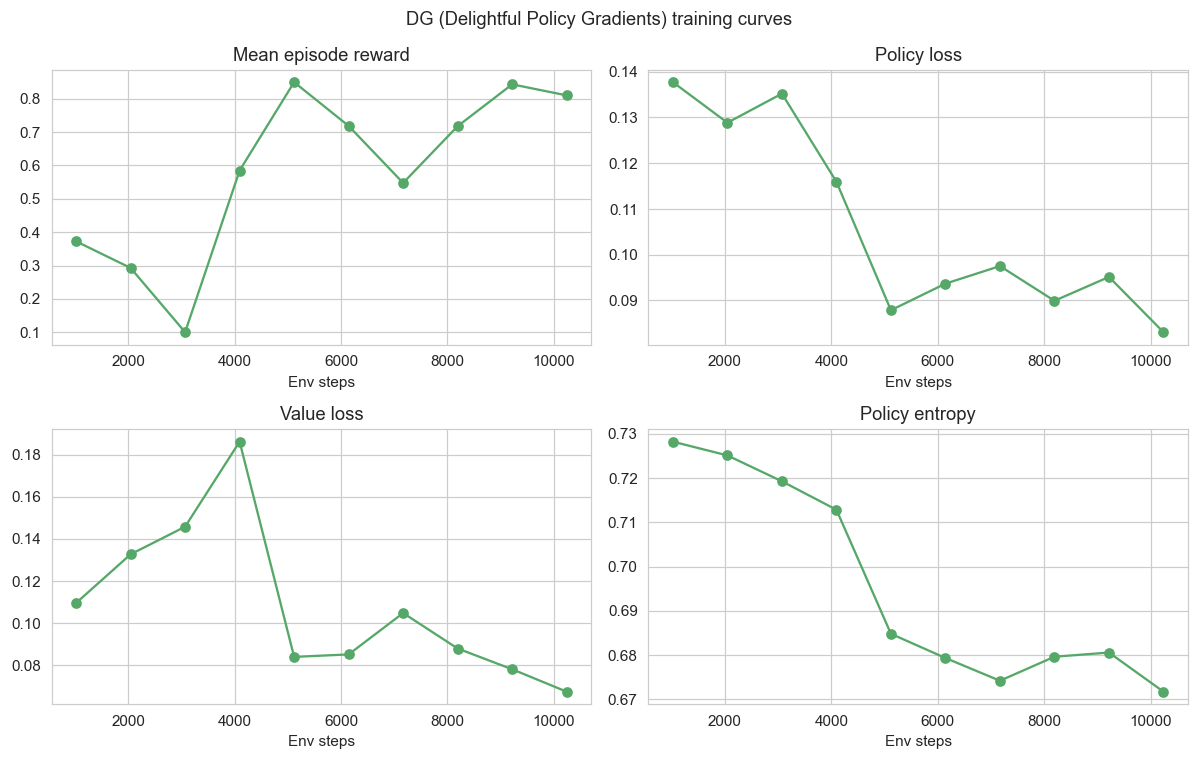

In [17]:
# Standard 2x2 learning curves
plot_training_curves(
    dg_history,
    "DG (Delightful Policy Gradients)",
    FIGURES_DIR / "06_dg_training.png",
    color="#55A868",
)

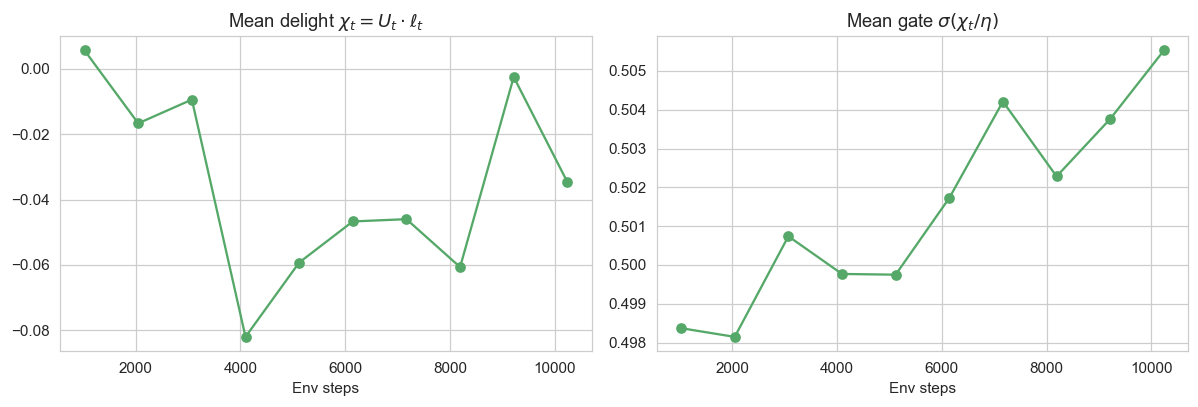

In [18]:
# DG-specific diagnostics: the delight signal and the gate
x = np.array(dg_history["steps"])
# Build a 1x2 figure: left = mean delight, right = mean gate
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
# Left: mean delight χ_t = U_t · ℓ_t averaged per rollout
ax[0].plot(x, dg_history["delight_mean"], color="#55A868", marker="o")
ax[0].set_title(r"Mean delight $\chi_t = U_t \cdot \ell_t$")
ax[0].set_xlabel("Env steps")
# Right: mean gate σ(χ_t / η) — values near 0.5 indicate uncommitted gating
ax[1].plot(x, dg_history["gate_mean"], color="#55A868", marker="o")
ax[1].set_title(r"Mean gate $\sigma(\chi_t / \eta)$")
ax[1].set_xlabel("Env steps")
# Layout + save
fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_dg_delight_gate.png")
plt.show()

---
## 7. Algorithm 3 — Soft PPO (Adaptive Entropy Tuning)

Soft PPO borrows SAC's trick of learning the entropy temperature α via **dual gradient descent**. Instead of a fixed `entropy_coeff`:

- **Target entropy:** $H^* = r \cdot \log |A|$ where $r$ is `target_entropy_ratio` (we use 0.5, i.e. keep the policy 50% as uncertain as uniform-random).
- **Policy loss:** $L^{CLIP} + c_v L_{value} - \alpha \cdot H(\pi)$ — same as PPO but with a learned α.
- **α update:** minimize $\alpha \cdot (H(\pi) - H^*)$ — drives α up when the policy becomes too deterministic and down when too random.

**Why?** Fixed entropy coefficients are brittle: too low and the policy collapses early, too high and it never commits. Soft PPO adapts automatically and yields more stable exploration curves.

In [19]:
# Build a Soft PPO config extending PPO with α-tuning knobs
soft_cfg = SoftPPOConfig(
    # Inherit every PPO hyperparam
    **{k: getattr(cfg.ppo, k) for k in cfg.ppo.__dataclass_fields__},
    # Target entropy fraction: 0.5 × log(7) ≈ 0.97 nats
    target_entropy_ratio=0.5,
    # Separate learning rate for log(α) so the entropy tuner reacts at its own timescale
    alpha_lr=3e-4,
)
# Instantiate Soft PPO — adds a learnable log_alpha parameter and α optimizer
soft_agent = SoftPPOLSTM(obs_dim=OBS_DIM, action_dim=ACTION_DIM, config=soft_cfg, device="cpu")
# Train and collect history (includes "alpha" and "alpha_loss" metrics each rollout)
soft_history = train_agent(soft_agent, train_env, DEMO_TIMESTEPS, DEMO_ROLLOUT, "SoftPPO")

[SoftPPO] rollout 2 | steps 2048/10000 | mean reward +0.114 | entropy 0.734


[SoftPPO] rollout 4 | steps 4096/10000 | mean reward +0.398 | entropy 0.723


[SoftPPO] rollout 6 | steps 6144/10000 | mean reward +0.632 | entropy 0.705


[SoftPPO] rollout 8 | steps 8192/10000 | mean reward +0.894 | entropy 0.685


[SoftPPO] rollout 10 | steps 10240/10000 | mean reward +1.004 | entropy 0.691


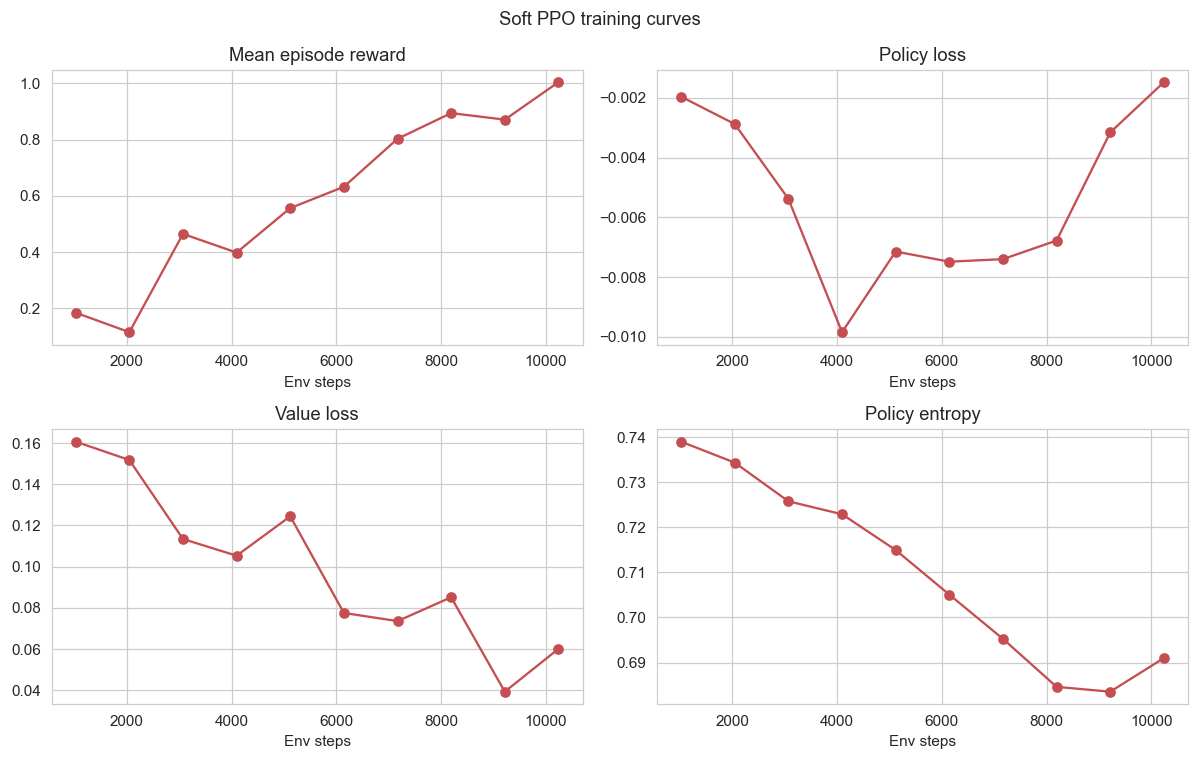

In [20]:
# Standard 2x2 learning curves for Soft PPO
plot_training_curves(
    soft_history,
    "Soft PPO",
    FIGURES_DIR / "08_soft_ppo_training.png",
    color="#C44E52",
)

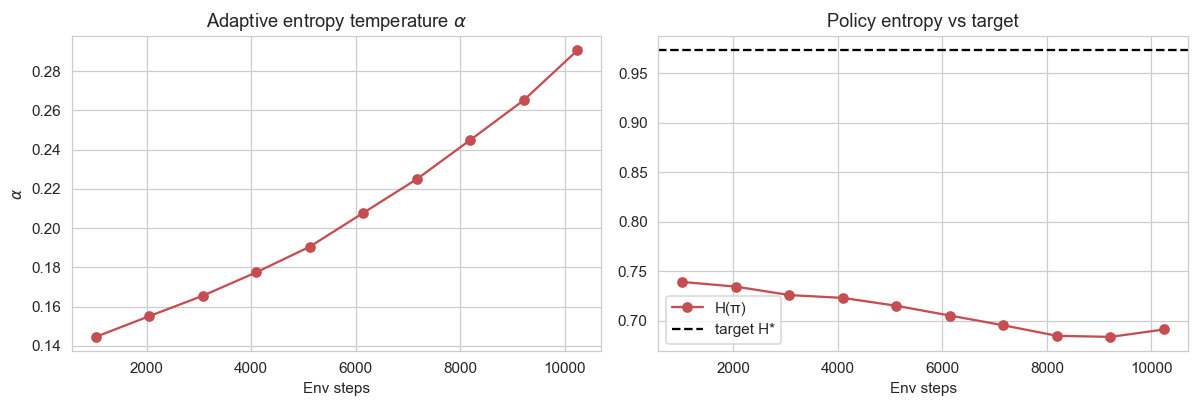

In [21]:
# Soft PPO specific diagnostic: the adaptive α over training vs. target entropy
x = np.array(soft_history["steps"])
# 1x2 figure: left = α, right = entropy vs target
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
# Left: adaptive entropy temperature α over training
ax[0].plot(x, soft_history["alpha"], color="#C44E52", marker="o")
ax[0].set_title(r"Adaptive entropy temperature $\alpha$")
ax[0].set_xlabel("Env steps")
ax[0].set_ylabel(r"$\alpha$")
# Right: observed entropy vs target entropy — should converge
ax[1].plot(x, soft_history["entropy"], color="#C44E52", marker="o", label="H(π)")
# Target is constant across training (set once in the config)
ax[1].axhline(soft_history["target_entropy"][0], color="k", linestyle="--", label="target H*")
ax[1].set_title("Policy entropy vs target")
ax[1].set_xlabel("Env steps")
ax[1].legend()
# Layout + save
fig.tight_layout()
fig.savefig(FIGURES_DIR / "09_soft_ppo_alpha.png")
plt.show()

---
## 8. Side-by-Side Comparison

Overlay the three algorithms on the same axes so their learning dynamics are directly comparable.

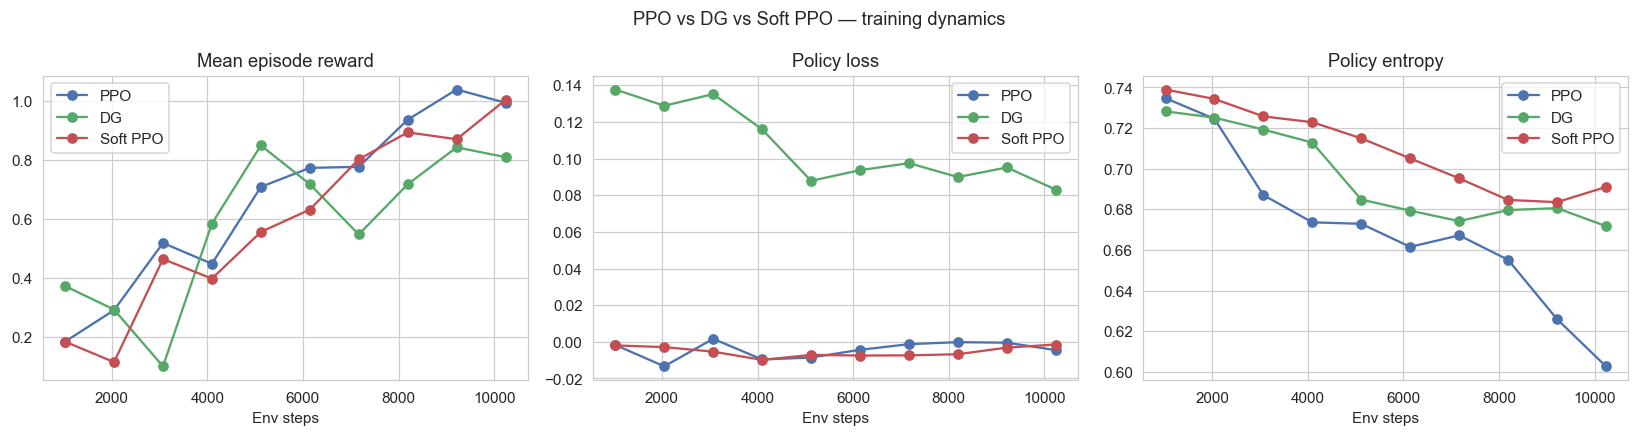

In [22]:
# Package the three histories into a list of (label, history, color) tuples
runs = [
    ("PPO", ppo_history, "#4C72B0"),
    ("DG", dg_history, "#55A868"),
    ("Soft PPO", soft_history, "#C44E52"),
]
# Three metrics we care most about for comparison
metrics = [
    ("reward", "Mean episode reward"),
    ("policy_loss", "Policy loss"),
    ("entropy", "Policy entropy"),
]
# 1x3 grid — one subplot per metric
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (key, title) in zip(axes, metrics):
    # Overlay all three runs on this metric
    for label, hist, color in runs:
        # Only plot if this history recorded the metric
        if key in hist and len(hist[key]) == len(hist["steps"]):
            ax.plot(hist["steps"], hist[key], marker="o", label=label, color=color)
    # Axis labels + legend per subplot
    ax.set_title(title)
    ax.set_xlabel("Env steps")
    ax.legend()
# Layout + save
fig.suptitle("PPO vs DG vs Soft PPO — training dynamics")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "10_comparison_training.png")
plt.show()

---
## 9. Evaluation on Held-Out Validation Set

The training curves only report reward on the (augmented) training distribution. The real test is whether each agent correctly classifies held-out sessions. We run each trained agent **deterministically** on the validation set and record outcomes.

In [23]:
# Deterministic evaluation: run each agent on n episodes, collect per-outcome counts
def evaluate(agent, env, n_episodes=100):
    # Count occurrences of every outcome string returned by env.step()
    outcomes = defaultdict(int)
    # Correct outcomes (the ones we get reward for in evaluate_ppo.py)
    correct_names = {"correct_block", "bot_blocked_puzzle", "correct_allow", "human_passed_puzzle"}
    # Count correct episodes separately so we can compute an accuracy
    correct = 0
    total = 0
    for _ in range(n_episodes):
        # Reset env + LSTM state before each episode
        obs, info = env.reset()
        agent.reset_hidden()
        # Skip too-short sessions
        while info.get("too_short"):
            obs, info = env.reset()
            agent.reset_hidden()
        # Use the valid-action mask from the env
        action_mask = info.get("action_mask")
        done = False
        step_info = {}
        # Run until the agent picks a terminal action
        while not done:
            # deterministic=True means "pick the argmax action" (no exploration)
            action, _, _ = agent.select_action(obs, action_mask=action_mask, deterministic=True)
            obs, reward, terminated, truncated, step_info = env.step(action)
            done = terminated or truncated
            action_mask = step_info.get("action_mask")
        # Record the terminal outcome label
        outcome = step_info.get("outcome", "unknown")
        outcomes[outcome] += 1
        if outcome in correct_names:
            correct += 1
        total += 1
    # Return both the aggregate accuracy and the full outcome breakdown
    return correct / total if total else 0.0, dict(outcomes)

# Evaluate every trained agent on the same validation env (augmentation is off)
EVAL_EPISODES = 80
# Store (label, accuracy, outcomes) for the comparison chart below
eval_results = []
for label, agent in [("PPO", ppo_agent), ("DG", dg_agent), ("Soft PPO", soft_agent)]:
    acc, outs = evaluate(agent, val_env, n_episodes=EVAL_EPISODES)
    eval_results.append((label, acc, outs))
    # Print a brief summary per agent
    print(f"{label:>10s}: accuracy = {acc:.3f}  |  outcomes = {outs}")

       PPO: accuracy = 0.963  |  outcomes = {'correct_allow': 36, 'bot_blocked_puzzle': 41, 'bot_passed_puzzle': 2, 'false_negative': 1}


        DG: accuracy = 0.950  |  outcomes = {'bot_blocked_puzzle': 33, 'correct_allow': 43, 'bot_passed_puzzle': 2, 'false_negative': 2}


  Soft PPO: accuracy = 0.963  |  outcomes = {'correct_allow': 34, 'bot_blocked_puzzle': 43, 'bot_passed_puzzle': 3}


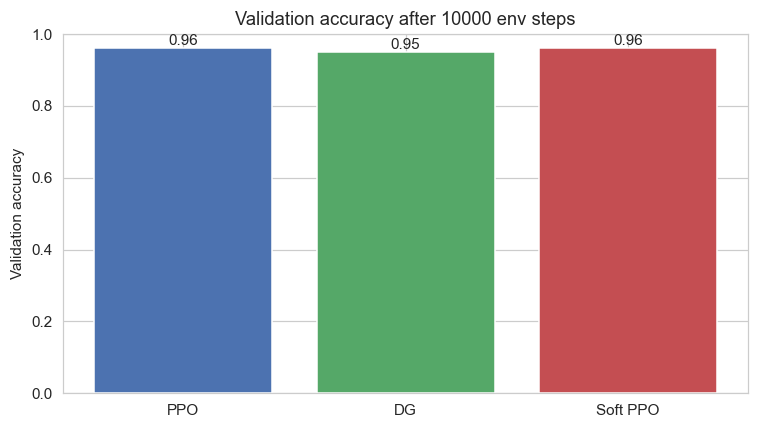

In [24]:
# Bar chart: validation accuracy per algorithm
labels = [r[0] for r in eval_results]
accs = [r[1] for r in eval_results]
# Build the figure
fig, ax = plt.subplots(figsize=(7, 4))
# Use the same per-algorithm colors as the training curves for visual consistency
colors_per = ["#4C72B0", "#55A868", "#C44E52"]
bars = ax.bar(labels, accs, color=colors_per)
# Annotate each bar with its accuracy value
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{a:.2f}", ha="center", va="bottom", fontsize=10)
# Cap the y-axis at 1.0 since accuracy is a proportion
ax.set_ylim(0, 1.0)
ax.set_ylabel("Validation accuracy")
ax.set_title(f"Validation accuracy after {DEMO_TIMESTEPS} env steps")
# Layout + save
fig.tight_layout()
fig.savefig(FIGURES_DIR / "11_validation_accuracy.png")
plt.show()

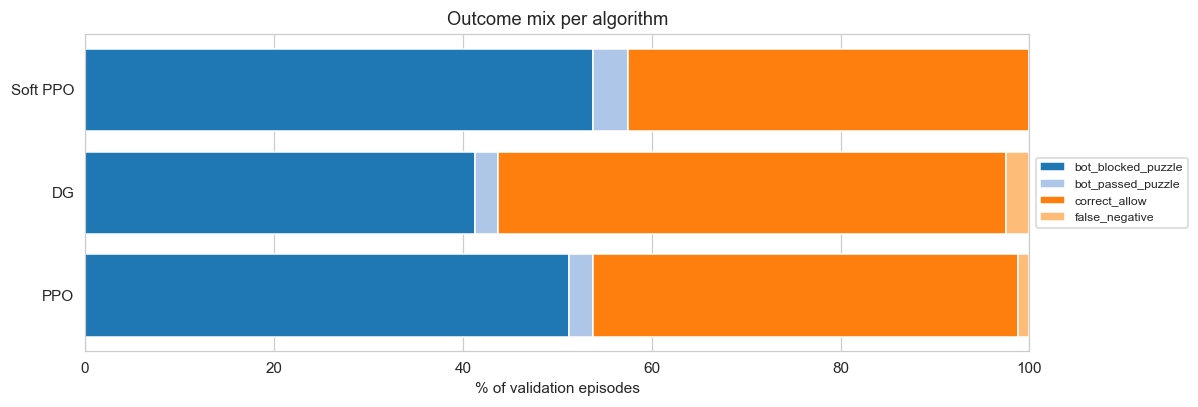

In [25]:
# Stacked bar chart: outcome breakdown per algorithm (what each agent actually decides)
# Union of every outcome label observed across the three runs — stable column ordering
all_outcomes = sorted({name for _, _, outs in eval_results for name in outs})
# Build an (n_algos, n_outcomes) matrix of counts so we can stack bars
matrix = np.array([[outs.get(name, 0) for name in all_outcomes] for _, _, outs in eval_results])
# Normalize each row to percentages so algorithms are comparable
row_totals = matrix.sum(axis=1, keepdims=True)
# Guard against a divide-by-zero if an algorithm produced no episodes
percent = np.where(row_totals > 0, 100.0 * matrix / row_totals, 0.0)
# Render a stacked horizontal bar chart
fig, ax = plt.subplots(figsize=(11, 3.8))
# Use a qualitative colormap with enough distinct colors
cmap = plt.get_cmap("tab20")
# Cumulative left-edge for stacking
lefts = np.zeros(len(labels))
for j, name in enumerate(all_outcomes):
    # Bar segment for outcome `name` across all algorithms
    widths = percent[:, j]
    ax.barh(labels, widths, left=lefts, color=cmap(j % 20), label=name)
    lefts += widths
# Axis labels + outside legend
ax.set_xlabel("% of validation episodes")
ax.set_title("Outcome mix per algorithm")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
# Layout + save
fig.tight_layout()
fig.savefig(FIGURES_DIR / "12_outcome_mix.png")
plt.show()

---
## 10. Summary & Next Steps

**What we built**
- Loaded all human / bot / augmented-bot sessions directly from `src/data/` and visualized the composition.
- Set up the windowed `EventEnv` with stratified 70/15/15 splits and action masking.
- Trained three algorithms on the same LSTM actor-critic:
  - **PPO** — clipped surrogate, the industry baseline.
  - **DG** — sigmoid-gated delightful policy gradient (arXiv:2603.14608).
  - **Soft PPO** — PPO with SAC-style adaptive entropy temperature α.
- Saved every figure to `notebook_figures/` and compared dynamics + validation accuracy.

**Interpreting the results**
The demo budget of `DEMO_TIMESTEPS = 10_000` is far below what's needed for any of these algorithms to converge — the full `train_ppo.py` pipeline uses **500,000** steps per run. Treat the accuracy numbers above as a **plumbing check**, not a performance benchmark. To reproduce publication-quality curves, run:
```bash
python -m rl_captcha.scripts.train_ppo --algorithm ppo --data-dir data/ \
    --save-path rl_captcha/agent/checkpoints/ppo_noaug --total-timesteps 500000
```
and repeat for `dg` and `soft_ppo`, with and without `--adversarial-augment`.

**All figures saved to:** `notebook_figures/`